## Dataset Overview

In this step, we load the Fake News and Real News datasets and examine their dimensions to understand the number of records and features available for analysis.

In [76]:
import pandas as pd
import numpy as np

fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

print("Fake News Shape:", fake.shape)
print("Real News Shape:", true.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


### Observation

- Fake News dataset contains 23,481 records.
- Real News dataset contains 21,417 records.
- Both datasets have 4 features.
- The datasets are relatively balanced and suitable for binary classification.

First Few Records

In [77]:
print("Fake News Dataset")
display(fake.head())

print("\nReal News Dataset")
display(true.head())

Fake News Dataset


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



Real News Dataset


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


Columns Names


In [78]:
print("Fake Dataset Columns:")
print(fake.columns)

print("\nReal Dataset Columns:")
print(true.columns)

Fake Dataset Columns:
Index(['title', 'text', 'subject', 'date'], dtype='str')

Real Dataset Columns:
Index(['title', 'text', 'subject', 'date'], dtype='str')


Data Types and Basic Info

In [79]:
print("Fake Dataset Info")
fake.info()

print("\n" + "="*50 + "\n")

print("Real Dataset Info")
true.info()

Fake Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


Real Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


## Missing Values Analysis

In this step, we check for missing values in both datasets to ensure data quality before preprocessing and model training.

In [80]:
print("Missing Values in Fake Dataset")
print(fake.isnull().sum())

print("\n" + "="*50 + "\n")

print("Missing Values in True Dataset")
print(true.isnull().sum())

Missing Values in Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64


Missing Values in True Dataset
title      0
text       0
subject    0
date       0
dtype: int64


## Duplicate Values Analysis

In this step, we identify duplicate records in both datasets to avoid bias and data leakage during model training.

In [81]:
print("Duplicate Rows in Fake Dataset:", fake.duplicated().sum())
print("Duplicate Rows in True Dataset:", true.duplicated().sum())

Duplicate Rows in Fake Dataset: 3
Duplicate Rows in True Dataset: 206


In [82]:
fake = fake.drop_duplicates()
true = true.drop_duplicates()

print(fake.shape)
print(true.shape)

(23478, 4)
(21211, 4)


### Observation

- Duplicate records were detected and removed.
- Removing duplicates helps prevent model bias and improves data quality.

### Create Target Labels

In [83]:
fake["label"] = 0
true["label"] = 1

print(fake["label"].value_counts())
print(true["label"].value_counts())

label
0    23478
Name: count, dtype: int64
label
1    21211
Name: count, dtype: int64


### Varification

In [84]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [85]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


### Observation

- A target variable named `label` was created.
- Fake news articles were assigned label 0.
- True news articles were assigned label 1.


Merge Both Datasets

In this step, we combine the fake and true news datasets into a single dataset for binary classification.

In [86]:
df=pd.concat([fake,true],axis=0)
print("combined dataset shape:",df.shape)

combined dataset shape: (44689, 5)


In [87]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [88]:
df.tail()

,title,text,subject,date,label
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",1


### Observation

- The fake and true news datasets were merged into a single dataset.
- The combined dataset contains both classes required for binary classification.
- The target variable `label` identifies fake and true news articles.

Shuffle Dataset

In this step, the dataset is randomly shuffled to ensure a balanced distribution of classes before model training.


In [89]:
df=df.sample(frac=1,random_state=42).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


### Observation
- The dataset was randomly shuffled.
- Shuffling prevents any ordering bias in the data.
- The dataset is now ready for exploratory data analysis and preprocessing.

.Class Distribution Analysis
In this step, we examine the distribution of fake and true news articles to identify any class imbalance.

In [90]:
df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

### Visualization

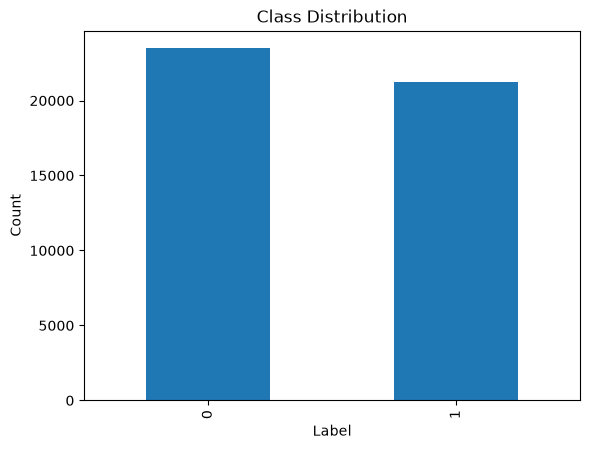

In [91]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Observation

- The dataset contains 23,478 fake news articles and 21,211 true news articles.
- The class distribution is relatively balanced.
- No major class imbalance is observed, making the dataset suitable for binary classification.

### EDA

## News Category Analysis

In this step, we analyze the distribution of news categories available in the dataset.

In [92]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

### Visualization

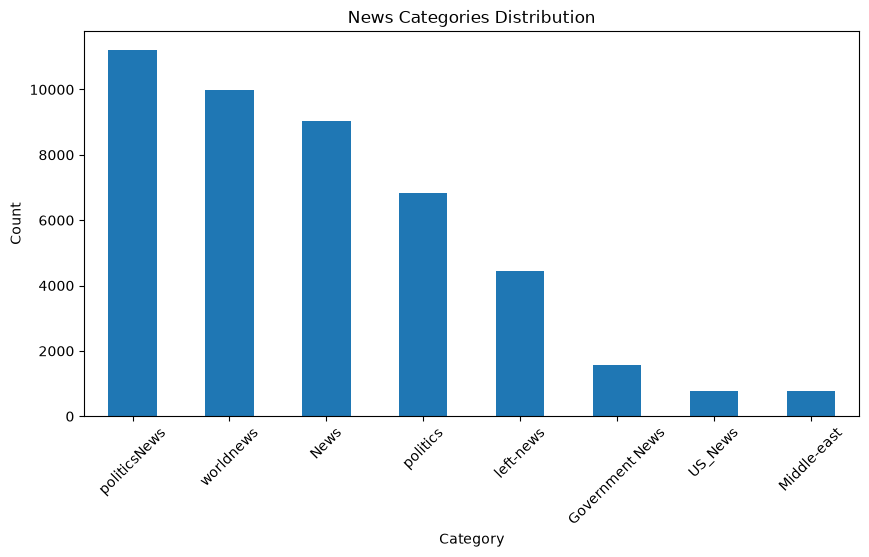

In [93]:
import matplotlib.pyplot as plt
df["subject"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("News Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Insights
- `politicsNews` is the most frequent category in the dataset.
- `worldnews` and `News` also contribute a significant portion of records.
- Most articles belong to political and current affairs domains.
- The dataset covers multiple news categories, which can improve model generalization.

### Text Length Analysis
In this step, we analyze the length of news articles to understand the distribution of textual content across the dataset.

In [94]:
df["text_length"]=df["text"].apply(len)
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

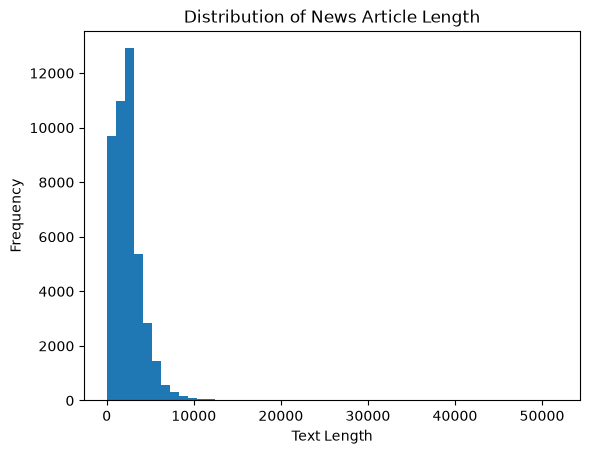

In [95]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(10,5))
plt.hist(df["text_length"],bins=50)

plt.title("Distribution of News Article Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [96]:
df.groupby("label")["text_length"].mean()

label
0    2547.555882
1    2378.042337
Name: text_length, dtype: float64

### Insights
- The average article length is approximately 2,467 characters.
- Most articles contain substantial textual content, making the dataset suitable for NLP tasks.

**** Fake articles are slightly longer than True articles.

In [97]:
df["text_length"].describe()

count    44689.000000
mean      2467.098682
std       2173.612347
min          1.000000
25%       1232.000000
50%       2185.000000
75%       3101.000000
max      51794.000000
Name: text_length, dtype: float64

In [98]:
df.groupby("label")["text_length"].mean()

label
0    2547.555882
1    2378.042337
Name: text_length, dtype: float64


### Check very short Articles..

In this step, we identify unusually short articles that may affect model performance and data quality.

In [99]:
df[df["text_length"] < 50][["title", "text", "label"]]

,title,text,label
17,OUTRAGEOUS! NANCY PELOSI Claims Obamacare Hono...,,0
27,EDUCATION SECRETARY BLOCKED And Harrassed Tryi...,,0
39,THE HORRIBLE END GAME: BERNIE SANDERS Calls fo...,,0
113,EPIC LIBERAL SMACKDOWN: “Burning Up The Street...,,0
162,MUST WATCH VIDEO! MEGYN KELLY SPELLS IT OUT FO...,,0
...,...,...,...
44531,(VIDEO) KRAUTHAMMER: FORMER CIA DEPUTY DIRECTO...,,0
44574,AWESOME! HISPANIC TRUMP SUPPORTER Rips Into Pr...,,0
44580,BOOM! JULIAN ASSANGE OF WIKILEAKS Drops A Trut...,,0
44649,OUTRAGEOUS VIDEO! OBAMA KEEPS STIRRING THE FLA...,,0


## Empty Text Removal

Some records contain empty article content. These records are removed because they do not provide meaningful information for text classification.

In [100]:
df = df[df["text"].str.strip() != ""]

print("Dataset Shape After Removing Empty Text Rows:")
print(df.shape)

Dataset Shape After Removing Empty Text Rows:
(44058, 6)


### Insights
- Records containing empty article content were removed from the dataset.
- The dataset size reduced from 44,689 to 44,058 records.
- Data quality improved by eliminating non-informative samples.


### Text Preprocessing (Core NLP)
In this step, textual data is cleaned by converting text to lowercase, removing URLs, special characters, numbers, and extra spaces to prepare it for feature extraction.

### For NLP Import Libraries

In [101]:
import re
import string

Cleaning Function


In [102]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    text = re.sub(r'\n', ' ', text)

    text = re.sub(r'\w*\d\w*', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

Apply Cleaning

In [103]:
df["clean_text"] = df["text"].apply(clean_text)

### Varifications

In [104]:
df[["text", "clean_text"]].head()

,text,clean_text
0,"A school librarian in Cambridge, Massachusetts...",a school librarian in cambridge massachusetts ...
1,NAIROBI (Reuters) - Kenyan opposition leader R...,nairobi reuters kenyan opposition leader raila...
2,CAIRO (Reuters) - Egypt rejected the U.S. deci...,cairo reuters egypt rejected the us decision t...
3,After a recent speech given by Minister Louis ...,after a recent speech given by minister louis ...
4,Tensions ran high outside of a campaign rally ...,tensions ran high outside of a campaign rally ...


### Insights 
- Text was successfully converted to lowercase.
- URLs, punctuation marks, and special characters were removed.
- Text became more structured and suitable for NLP processing.
- A cleaned version of the article content was stored in the `clean_text` column.

In [105]:
for i in range(5):
    print("Original Text:")
    print(df["text"].iloc[i][:300])

    print("\nCleaned Text:")
    print(df["clean_text"].iloc[i][:300])

    print("\n" + "="*100 + "\n")

Original Text:
A school librarian in Cambridge, Massachusetts, rejected a shipment of books that were donated by first lady Melania Trump, according to CBS Boston.#HBFamilyReading: "Dear Mrs. Trump": @reflectlibrary says, Thanks but no thanks to the First Lady + Dr. Seuss  https://t.co/98SUPkjUN6 pic.twitter.com/3

Cleaned Text:
a school librarian in cambridge massachusetts rejected a shipment of books that were donated by first lady melania trump according to cbs bostonhbfamilyreading dear mrs trump reflectlibrary says thanks but no thanks to the first lady dr seuss the horn book hornbook september boston on wednesday repo


Original Text:
NAIROBI (Reuters) - Kenyan opposition leader Raila Odinga called for calm on Sunday as he visited a slum in the capital that was hit by violence when a political stand-off over a repeat presidential election fed into rising ethnic tensions. Clashes in Kawangware and in a village in western Kenya fol

Cleaned Text:
nairobi reuters kenyan opposition l

### Stopword Removal
 Words like:the,is,am,are,was,were,in,on,at

In [106]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [107]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [108]:
def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [109]:
df["clean_text"] = df["clean_text"].apply(remove_stopwords)

### Varification

In [110]:
print(df["clean_text"].iloc[0][:500])

school librarian cambridge massachusetts rejected shipment books donated first lady melania trump according cbs bostonhbfamilyreading dear mrs trump reflectlibrary says thanks thanks first lady dr seuss horn book hornbook september boston wednesday reported liz phipps soeiro cambridgeport elementary school turned works trump intended sendthe white house chose one school states receive package books authored children literary author dr seussthe initiative meant promote education childhood literac


### Markdown
- Common English stopwords were removed from the text.
- The remaining words carry more meaningful information for classification.
- This reduces noise and improves feature extraction efficiency.

TF-IDF Feature Extraction:it converts the textual news into machine-readable numerical features for model training 

In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)
X = tfidf.fit_transform(df["clean_text"])
y = df["label"]
print(X.shape)
print(y.shape)

(44058, 5000)
(44058,)


## Train-Test Split
The dataset was divided into training and testing subsets.
- Training Data: 80%
- Testing Data: 20%
This ensures that the model is evaluated on unseen data, providing a realistic measure of its generalization performance.

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (35246, 5000)
X_test : (8812, 5000)
y_train: (35246,)
y_test : (8812,)


## Logistic Regression Model Training
A Logistic Regression classifier was trained on TF-IDF features extracted from the news articles.

Logistic Regression is a widely used algorithm for binary classification tasks and serves as a strong baseline model for fake news detection.

In [113]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Model Training Completed ✅")

Model Training Completed ✅


In [114]:
print(type(lr_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


## Model Evaluation
The trained Logistic Regression model was evaluated on the test dataset.
Performance metrics including Accuracy, Precision, Recall, and F1-Score were used to assess the effectiveness of the classifier in distinguishing between fake and real news articles.

In [115]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)
y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9891057648660917

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4570
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8812
   macro avg       0.99      0.99      0.99      8812
weighted avg       0.99      0.99      0.99      8812



## Confusion Matrix Analysis
A confusion matrix was generated to visualize the classification performance of the Logistic Regression model.
The matrix highlights correctly classified instances as well as misclassifications, providing deeper insights into model behavior.

In [116]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4503   67]
 [  29 4213]]


### Visualization

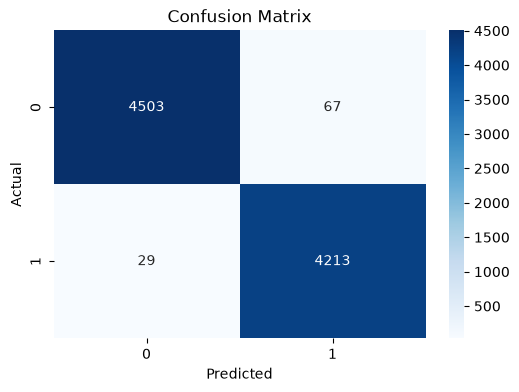

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Save Model & Vectorizer

In [118]:
import joblib
joblib.dump(lr_model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Model and Vectorizer Saved Successfully ✅")

Model and Vectorizer Saved Successfully ✅


### Verify


In [119]:
import os

print(os.getcwd())

c:\Users\Hp\OneDrive\Desktop\fake-news-analyzer\notebooks


In [120]:
import shutil

shutil.move(
    "fake_news_model.pkl",
    "../models/fake_news_model.pkl"
)

shutil.move(
    "tfidf_vectorizer.pkl",
    "../models/tfidf_vectorizer.pkl"
)

print("✅ Files moved successfully")

✅ Files moved successfully


## Verify

In [121]:
import os

print(os.listdir("../models"))

['fake_news_model.pkl', 'tfidf_vectorizer.pkl']
